# Testing
## Todesfälle nach aggregierter Todesursache, Altersklasse und Geschlecht

### Beschreibung
Diese Daten beinhalten Todesursachen nach Altersklasse und Geschlecht. Die Todesursachen stammen vom Bundesamt für Statistik und wurden mit den Daten des Bevölkerungsregisters der Stadt Zürich verknüpft.

Datum: 17.01.2025

Diese Daten beinhalten aggregierte Todesursachen nach Altersklasse und Geschlecht. Die Todesursachen stammen vom Bundesamt für Statistik und wurden mit den Daten des Bevölkerungsregisters der Stadt Zürich verknüpft.

Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_bevreg_todesursache-aggregiert_alter_geschlecht_seit1995_od3120

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bevreg_todesursache-aggregiert_alter_geschlecht_seit1995_od3120

**Importiere die notwendigen Packages**

In [1]:
#pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bfs_bevreg_todesursache-aggregiert_alter_geschlecht_seit1995_od3120"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'dropzone'
    , package_name = package_name
    , dataset_name = "BEV312OD3120"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH\bfs_bevreg_todesursache-aggregiert_alter_geschlecht_seit1995_od3120\BEV312OD3120.csv
data_source: dropzone


In [10]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1995-01-01 00:00:00,1995-01-01 00:00:00
TodesursacheSpezSort_noDM,200,200
TodesursacheSpezCd_noDM,200,200
TodesursacheSpezLang_noDM,Krebskrankheiten,Krebskrankheiten
SexCd,1,1
SexKurz,M,M
SexLang,männlich,männlich
AlterVTod2Sort_noDM,1,2
AlterVTod2Cd_noDM,1,2
AlterVTod2Lang_noDM,unter 15 Jahre alt,15-44 Jahre alt


Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr              datetime64[ns]
TodesursacheSpezSort_noDM             int64
TodesursacheSpezCd_noDM               int64
TodesursacheSpezLang_noDM            object
SexCd                                 int64
SexKurz                              object
SexLang                              object
AlterVTod2Sort_noDM                   int64
AlterVTod2Cd_noDM                     int64
AlterVTod2Lang_noDM                  object
AnzSterWir                            int64
StichtagDatJahr_str                  object
Jahr                         datetime64[ns]
Jahr_end                     datetime64[ns]
Jahr_nbr                              int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [12]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1995 und ein Maximumjahr von 2024


### Einfache Datentests

In [13]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1446 entries, 1445 to 0
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   StichtagDatJahr            1446 non-null   datetime64[ns]
 1   TodesursacheSpezSort_noDM  1446 non-null   int64         
 2   TodesursacheSpezCd_noDM    1446 non-null   int64         
 3   TodesursacheSpezLang_noDM  1446 non-null   object        
 4   SexCd                      1446 non-null   int64         
 5   SexKurz                    1446 non-null   object        
 6   SexLang                    1446 non-null   object        
 7   AlterVTod2Sort_noDM        1446 non-null   int64         
 8   AlterVTod2Cd_noDM          1446 non-null   int64         
 9   AlterVTod2Lang_noDM        1446 non-null   object        
 10  AnzSterWir                 1446 non-null   int64         
 11  StichtagDatJahr_str        1446 non-null   object        
 12  Jahr       

In [14]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,446 rows (observations) and 15 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [15]:
data2betested.describe()

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,SexCd,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AnzSterWir,Jahr,Jahr_end,Jahr_nbr
count,1446,1446,1446,1446,1446,1446,1446,1446,1446,1446
mean,2009-04-15 22:32:21.908713728,705,705,1,3,3,73,2009-04-15 22:32:21.908713728,2010-04-15 05:01:44.564315392,2009
min,1995-01-01 00:00:00,200,200,1,1,1,1,1995-01-01 00:00:00,1995-12-31 00:00:00,1995
25%,2002-01-01 00:00:00,400,400,1,2,2,11,2002-01-01 00:00:00,2002-12-31 00:00:00,2002
50%,2009-01-01 00:00:00,600,600,1,3,3,37,2009-01-01 00:00:00,2009-12-31 00:00:00,2009
75%,2017-01-01 00:00:00,1100,1100,2,4,4,89,2017-01-01 00:00:00,2017-12-31 00:00:00,2017
max,2024-01-01 00:00:00,1200,1200,2,5,5,626,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,381,381,1,1,1,95,NaN,NaN,9


Welches sind die Quartiere ohne Werte bei BEW?

In [16]:
data2betested[np.isnan(data2betested.AnzSterWir)]

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,SexCd,SexKurz,SexLang,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AlterVTod2Lang_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [17]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [18]:
data2betested.index.year.unique()

Index([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [19]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [20]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,SexCd,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AnzSterWir,Jahr_nbr
count,"1,446","1,446","1,446","1,446","1,446","1,446","1,446"
mean,705,705,1,3,3,73,"2,009"
std,381,381,1,1,1,95,9
min,200,200,1,1,1,1,"1,995"
25%,400,400,1,2,2,11,"2,002"
50%,600,600,1,3,3,37,"2,009"
75%,"1,100","1,100",2,4,4,89,"2,017"
max,"1,200","1,200",2,5,5,626,"2,024"


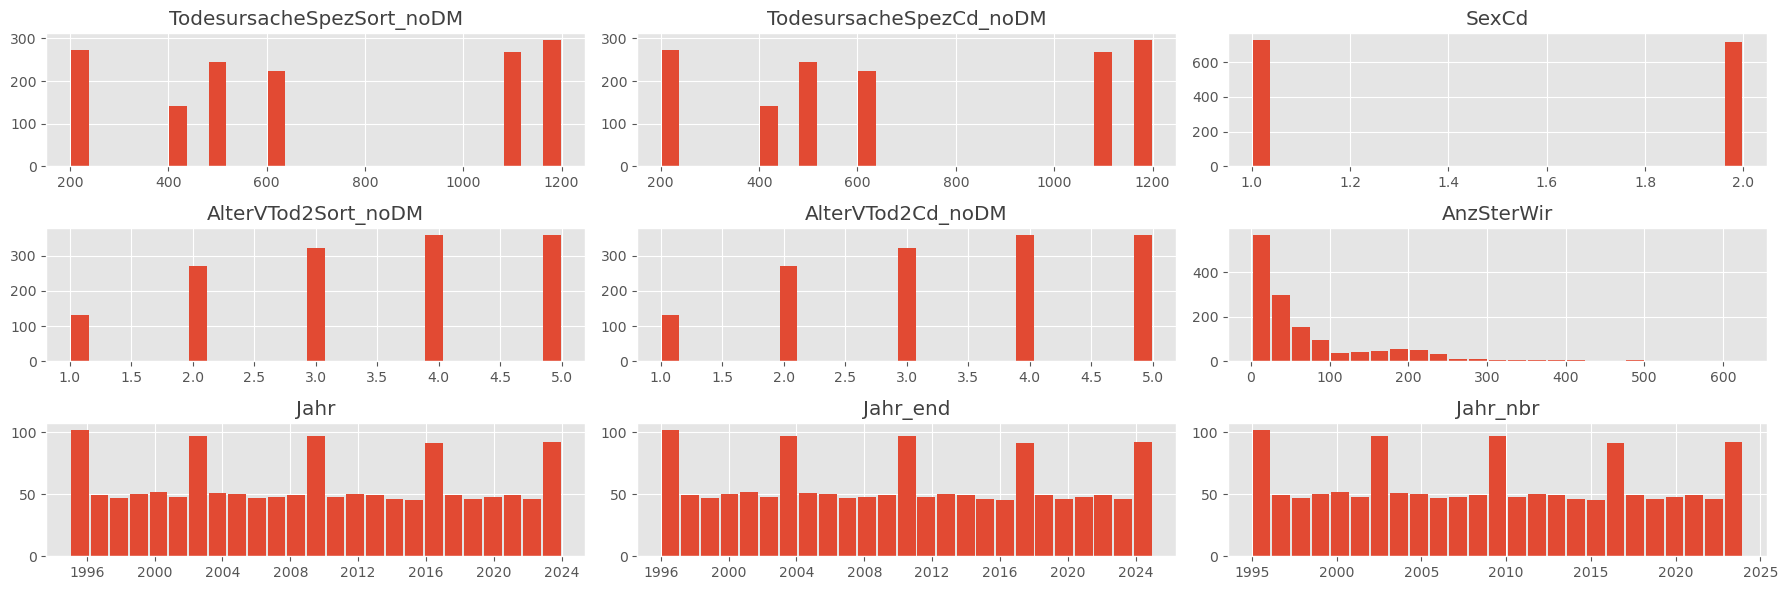

In [21]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [22]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,SexCd,SexKurz,SexLang,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AlterVTod2Lang_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [23]:
data2betested.isnull().sum()

TodesursacheSpezSort_noDM    0
TodesursacheSpezCd_noDM      0
TodesursacheSpezLang_noDM    0
SexCd                        0
SexKurz                      0
SexLang                      0
AlterVTod2Sort_noDM          0
AlterVTod2Cd_noDM            0
AlterVTod2Lang_noDM          0
AnzSterWir                   0
StichtagDatJahr_str          0
Jahr                         0
Jahr_end                     0
Jahr_nbr                     0
dtype: int64

In [24]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [25]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,Sum_AnzSterWir
0,2024-01-01,2024,2024-12-31,3063
1,2023-01-01,2023,2023-12-31,3106
2,2022-01-01,2022,2022-12-31,3350


In [26]:
agg_sex = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['SexCd','SexKurz', 'SexLang',]) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('SexCd', ascending=False) 
agg_sex.reset_index().head(3)

,SexCd,SexKurz,SexLang,Sum_AnzSterWir
0,2,W,weiblich,58694
1,1,M,männlich,47230


In [27]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterVTod2Sort_noDM', 'AlterVTod2Cd_noDM','AlterVTod2Lang_noDM']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('AlterVTod2Sort_noDM', ascending=False) 
agg_age.reset_index().head(11)

,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AlterVTod2Lang_noDM,Sum_AnzSterWir
0,5,5,85 Jahre und älter,46842
1,4,4,65-84 Jahre alt,43291
2,3,3,45-64 Jahre alt,11524
3,2,2,15-44 Jahre alt,3652
4,1,1,unter 15 Jahre alt,615


In [28]:
data2betested.columns

Index(['TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM', 'TodesursacheSpezLang_noDM',
       'SexCd', 'SexKurz', 'SexLang', 'AlterVTod2Sort_noDM', 'AlterVTod2Cd_noDM',
       'AlterVTod2Lang_noDM', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [29]:
agg_tdurs = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM', 'TodesursacheSpezLang_noDM']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodesursacheSpezSort_noDM', ascending=True) 
agg_tdurs.reset_index().head(35)

,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,Sum_AnzSterWir
0,200,200,Krebskrankheiten,23848
1,400,400,Demenz,9667
2,500,500,Kreislaufsystem,36478
3,600,600,Atmungsorgane,5651
4,1100,1100,Unfälle und Gewalteinwirkungen,6471
5,1200,1200,Alle übrigen Todesursachen,23809


### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Sterbefälle nach Todesursache

In [30]:
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','Jahr_nbr','TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM', 'TodesursacheSpezLang_noDM']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodesursacheSpezSort_noDM', ascending=True) 
myAgg1.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,Sum_AnzSterWir
0,1995-01-01,1995,200,200,Krebskrankheiten,1004
1,2000-01-01,2000,200,200,Krebskrankheiten,838
2,2015-01-01,2015,200,200,Krebskrankheiten,791


In [31]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'Sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Sterbefälle'
    ,category = "TodesursacheSpezLang_noDM:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Sterbefälle nach Todesursachen, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [32]:
myAgg1.reset_index().dtypes

StichtagDatJahr              datetime64[ns]
Jahr_nbr                              int32
TodesursacheSpezSort_noDM             int64
TodesursacheSpezCd_noDM               int64
TodesursacheSpezLang_noDM            object
Sum_AnzSterWir                        int64
dtype: object

In [33]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('TodesursacheSpezSort_noDM == 200 ').sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'Sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Sterbefälle'
    ,category = "TodesursacheSpezLang_noDM:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Sterbefälle durch Krebserkrankungen, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

In [34]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('TodesursacheSpezSort_noDM == 1100 ').sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'Sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Sterbefälle'
    ,category = "TodesursacheSpezLang_noDM:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Sterbefälle durch Unfälle und Gewalteinwirkung, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

In [35]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik1)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2, grafik3, spacing=20)


# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#efefef",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [36]:
data2betested.columns

Index(['TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM', 'TodesursacheSpezLang_noDM',
       'SexCd', 'SexKurz', 'SexLang', 'AlterVTod2Sort_noDM', 'AlterVTod2Cd_noDM',
       'AlterVTod2Lang_noDM', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [37]:
myFG = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','Jahr_nbr','TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM', 'TodesursacheSpezLang_noDM','SexCd', 'SexKurz', 'SexLang',]) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodesursacheSpezSort_noDM', ascending=True) 
myFG.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,SexCd,SexKurz,SexLang,Sum_AnzSterWir
0,1995-01-01,1995,200,200,Krebskrankheiten,1,M,männlich,483
1,2000-01-01,2000,200,200,Krebskrankheiten,1,M,männlich,434
2,2024-01-01,2024,200,200,Krebskrankheiten,1,M,männlich,353


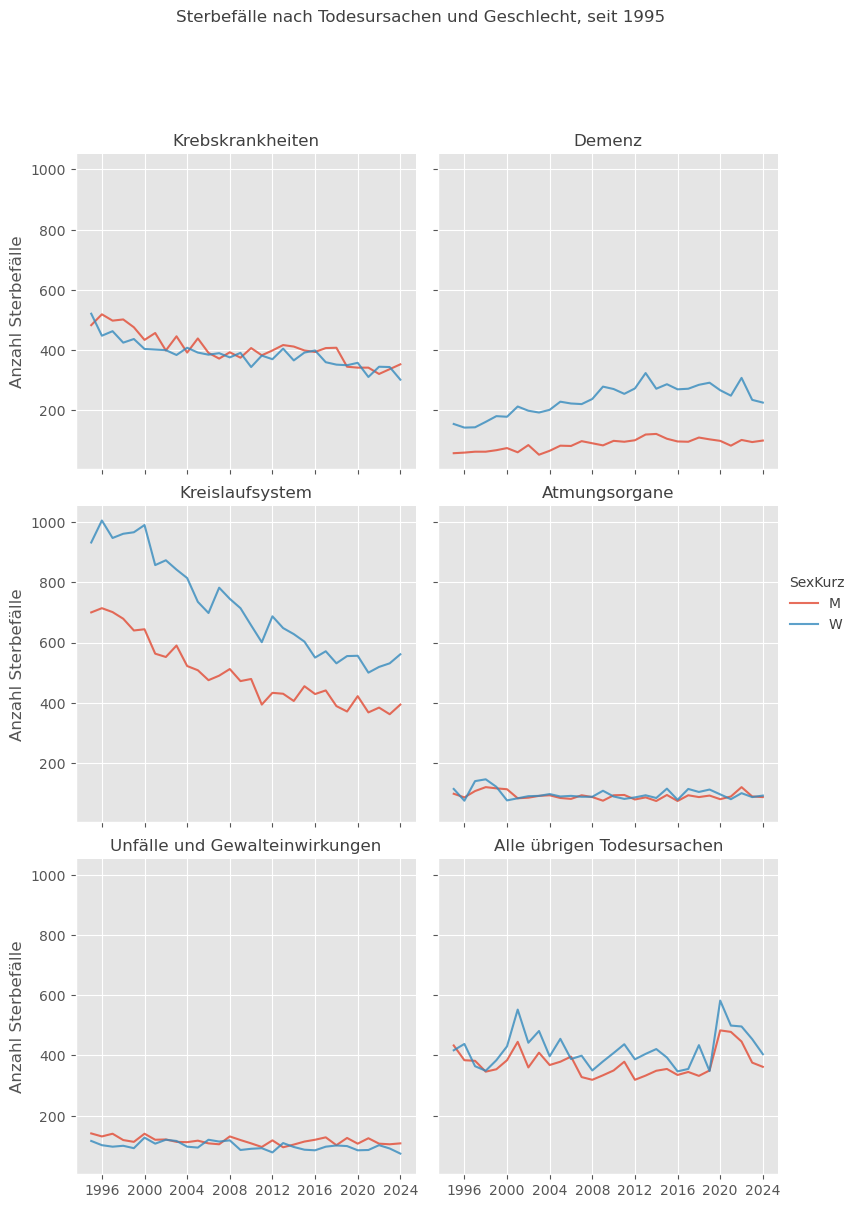

In [38]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,col = "TodesursacheSpezLang_noDM"
    ,hue = "SexKurz"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Sum_AnzSterWir"
    ,ylabel= "Anzahl Sterbefälle"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Sterbefälle nach Todesursachen und Geschlecht, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [39]:
myFG2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','Jahr_nbr','TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM','TodesursacheSpezLang_noDM','AlterVTod2Sort_noDM','AlterVTod2Cd_noDM', 'AlterVTod2Lang_noDM']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodesursacheSpezSort_noDM', ascending=True) 
myFG2.reset_index().head(3)

,StichtagDatJahr,Jahr_nbr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AlterVTod2Lang_noDM,Sum_AnzSterWir
0,1995-01-01,1995,200,200,Krebskrankheiten,1,1,unter 15 Jahre alt,2
1,2004-01-01,2004,200,200,Krebskrankheiten,2,2,15-44 Jahre alt,22
2,2004-01-01,2004,200,200,Krebskrankheiten,3,3,45-64 Jahre alt,149


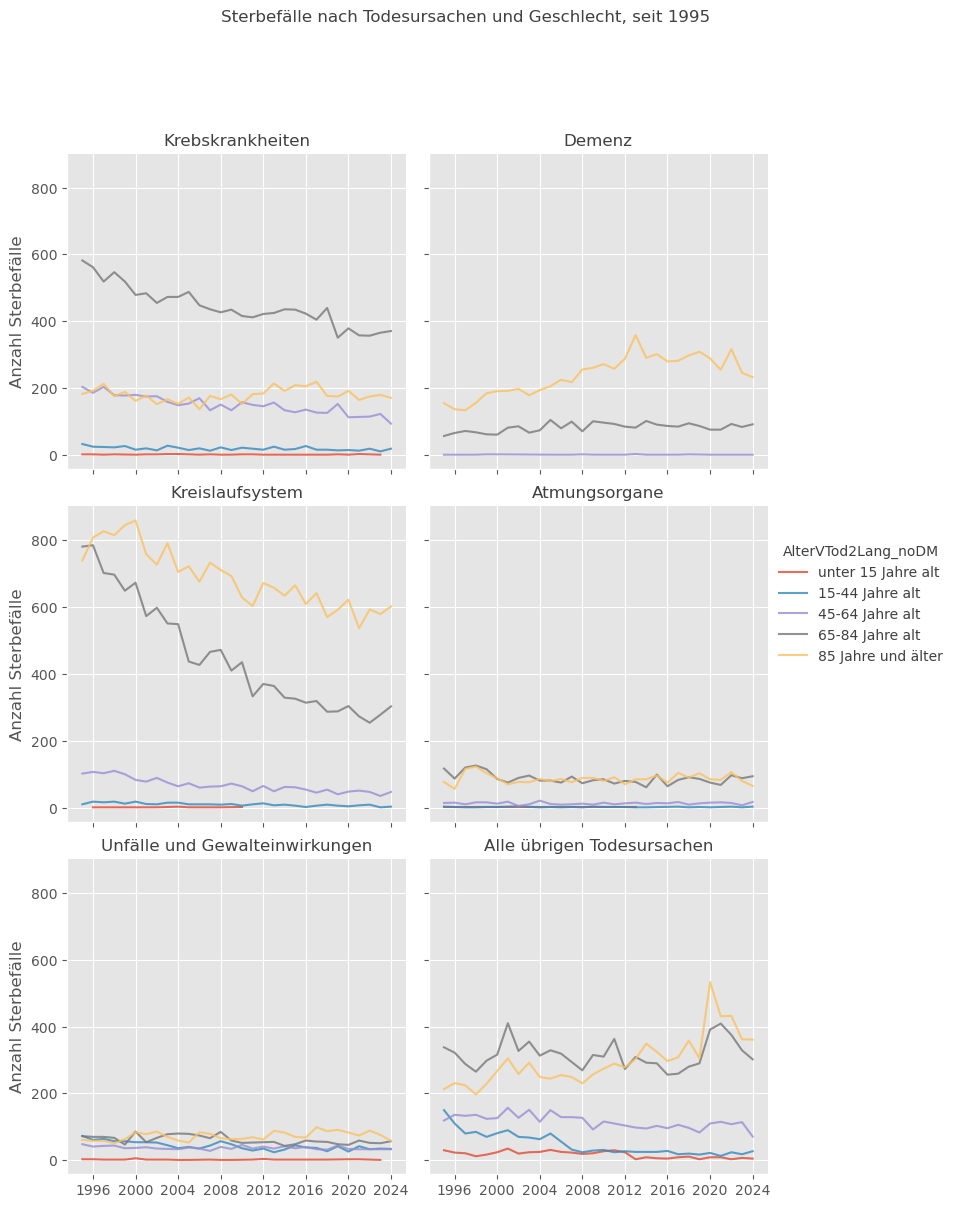

In [40]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,col = "TodesursacheSpezLang_noDM"
    ,hue = "AlterVTod2Lang_noDM"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "Sum_AnzSterWir"
    ,ylabel= "Anzahl Sterbefälle"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Sterbefälle nach Todesursachen und Geschlecht, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [41]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [42]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['TodesursacheSpezLang_noDM'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Krebskrankheiten': '#0017BF', 'Demenz': '#0072D7', 'Atmungsorgane': '#00A5D2', 'Kreislaufsystem': '#5E359A', 'Unfälle und Gewalteinwirkungen': '#BA0062', 'Alle übrigen Todesursachen': '#DA5563'}


In [43]:
myTM = data2betested
myTM.reset_index().head(2)

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,SexCd,SexKurz,SexLang,AlterVTod2Sort_noDM,AlterVTod2Cd_noDM,AlterVTod2Lang_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1995-01-01,200,200,Krebskrankheiten,1,M,männlich,1,1,unter 15 Jahre alt,1,1995-01-01,1995-01-01,1995-12-31,1995
1,1995-01-01,200,200,Krebskrankheiten,1,M,männlich,5,5,85 Jahre und älter,82,1995-01-01,1995-01-01,1995-12-31,1995


In [44]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['TodesursacheSpezLang_noDM', 'AlterVTod2Lang_noDM','SexLang', 'Jahr_nbr']
    ,values="AnzSterWir"
    ,color="AnzSterWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Sterbefälle nach Todesursache, Geschlecht und Altersgruppe, seit "+data_min_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000015C2502D390>, 'TodesursacheSpezLang_noDM', 'AlterVTod2Lang_noDM', 'SexLang', 'Jahr_nbr']
Typ von path: <class 'list'>


In [45]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM',
       'TodesursacheSpezLang_noDM', 'SexCd', 'SexKurz', 'SexLang', 'AlterVTod2Sort_noDM',
       'AlterVTod2Cd_noDM', 'AlterVTod2Lang_noDM', 'AnzSterWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [46]:
myTM2 = data2betested.loc[data_max_date]\
    .groupby(['StichtagDatJahr','TodesursacheSpezSort_noDM', 'TodesursacheSpezCd_noDM','TodesursacheSpezLang_noDM', 'AlterVTod2Lang_noDM','SexLang']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodesursacheSpezSort_noDM', ascending=True) 
myTM2.reset_index().head(3)

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,TodesursacheSpezLang_noDM,AlterVTod2Lang_noDM,SexLang,Sum_AnzSterWir
0,2024-01-01,200,200,Krebskrankheiten,15-44 Jahre alt,männlich,9
1,2024-01-01,200,200,Krebskrankheiten,15-44 Jahre alt,weiblich,10
2,2024-01-01,200,200,Krebskrankheiten,45-64 Jahre alt,männlich,56


In [47]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['TodesursacheSpezLang_noDM','AlterVTod2Lang_noDM','SexLang']
    ,values="Sum_AnzSterWir"
    ,color="TodesursacheSpezLang_noDM"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1200             
    #,margin_val_bottom=25
    ,myHeaderTitle="Sterbefälle nach Todesursache, "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000015C25BEBD10>, 'TodesursacheSpezLang_noDM', 'AlterVTod2Lang_noDM', 'SexLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=105&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------